
# Lab 3: PDE with FDM

#### **Exercise 1**: Finite-differences method (FDM) with tolerance **Jacobi method**.


Laplace's equation in the dominio $0\leq x \leq L$ and $0\leq y \leq L$ with Dirichlet's boundary conditions:

* $u(x,0)=V(x)=f(x)\to V_0=100$ V
* $u(0,y)=0$
* $u(L,y)=0$
* $u(x,L)=0$

1. Solve the Laplace's equation using finite differences for an specific tolerance ($10^{-6}<\text{tol}<10^{-1}$). Do a plot of the field $u(x,y)$ for $\text{tol}=10^{-3}$. Explain in your own words the strategy followed.
<p style="color: red;">2. Compare with the **Fourier serie**. How many terms in the Fourier serie are necessary to get a $\text{tol}=10^{-4}$?</p>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# Función principal para la propagación hecha con diferencias finitas
def Laplace2D_FDM(V_ini, tol, Nmax_iter):
    Nmax = V_ini.shape[0]
    V = V_ini.copy()
    
    for it in range(Nmax_iter):
        V_old = V.copy()
        
        # Algoritmo visto en clase
        for i in range(1, Nmax-1):
            for j in range(1, Nmax-1):
                V[i,j] = 0.25 * (V[i+1,j] + V[i-1,j] + V[i,j+1] + V[i,j-1])
        
        # diferencia máxima respecto al paso anterior
        diff = np.max(np.abs(V - V_old))
        
        # Si el cambio es menor que la tolerancia, detenemos el ciclo
        if diff < tol:
            print(f"Convergió en {it+1} iteraciones")
            return V
            
    print("Número máximo de iteraciones sin cumplir la tolerancia")
    return V

Número máximo de iteraciones sin cumplir la tolerancia


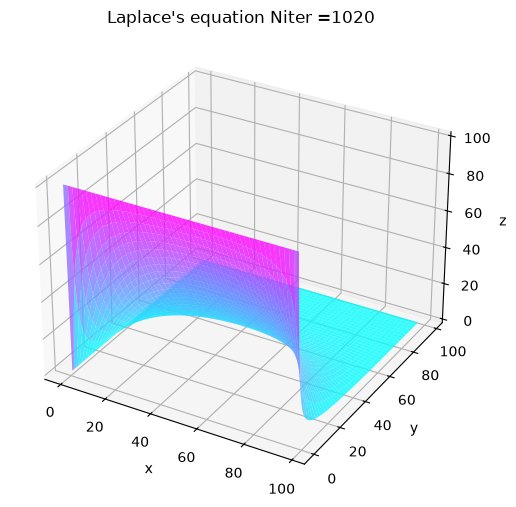

In [22]:
def grid(V_ini,x,y):
  'to compute x,y,z'
  V = V_ini.copy()
  X, Y = np.meshgrid(x,y)
  Z = V[X,Y] #filed value
  #return grid
  return X,Y,Z

Nmax, Niter = 100, 1020

# Initial V matrix
V_ini = np.zeros((Nmax, Nmax), float) # grid in 0V.
for k in range(0, Nmax):
  V_ini[k,0] = 100. # inerior a 100 V

# Do the grid to plot
x = np.arange(0, Nmax-1, 1)
y = x

# Run Laplace2D rutine
V = Laplace2D_FDM(V_ini, tol=10e-3, Nmax_iter=Niter)
X,Y,Z = grid(V,x,y)

# Plot the field
fig = plt.figure(figsize=(8, 6))
ax = plt.axes(projection='3d')
ax.plot_surface(X, Y, Z, cmap='cool', alpha=0.8)
ax.set_title('Laplace\'s equation Niter =%.1d'%Niter)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
plt.show()

#### **Exercise 2**: FDM for oppen boundaries (bonus!)

1. Solve **analytically** the Laplace's equation for $u(x,y)$ in the dominio $0\leq x \leq L$ and $0\leq y < \infty $, with Dirichlet's boundary conditions:

* $u(x,0)=V(x)=f(x) = u_0\sin(2\pi x/L)e^{-2\pi y/L}$
* $u(0,y)=0$
* $u(L,y)=0$
* $u(x,\infty)=0$,

Explain in your own words the strategy followed and write the analytical result.


1. Solve **numerically** the Laplace's equation, set the lenght $L=N\Delta = 100$ and $\Delta=1$ and $u_0=100$.

<img src="https://github.com/anferivera/Fisica_Computacional_1/raw/main/Sesiones/PDE/figures/Laplace_df_4.png" width="200" height="300" />

## Electric filed and potential in a parallel-plate capacitor

#### **Exercise 3** 

To find the potential generated by a capacitor  of two rectangular plates of width $d$ is challenging (see figure). In general, we can do some approximation based in infinite plates to get an intuition of the solution. In this approximation we have:


\begin{equation}
|\vec{E}| \approx \dfrac{\sigma}{2\epsilon_0}, \text{inside}\,,
\end{equation}

\begin{equation}
|\vec{E}| \approx 0, \text{  outside}\,.
\end{equation}


However, we know that the potential $\phi$ and the electric field $\vec{E}$ fulfill the Laplace's equation $\nabla^2\phi = 0$ in the region around the plates (where $\rho=0$).

1. Use finite differences to solve the Laplace's equation in the neigborhood of this capacitor. Use the imshow or the contour function to plot the potential.

2. Compute numerically the electric field (use finite difference method).

<img src="https://github.com/anferivera/Fisica_Computacional_1/raw/main/Sesiones/PDE/figures/Laplace_df_capacitor.png" alt="drawing" width="600"/>

Convergió en 33 iteraciones
Convergió en 44 iteraciones
Convergió en 53 iteraciones
Convergió en 60 iteraciones
Convergió en 66 iteraciones
Convergió en 71 iteraciones
Convergió en 75 iteraciones
Convergió en 79 iteraciones
Convergió en 82 iteraciones
Convergió en 86 iteraciones
Convergió en 89 iteraciones
Convergió en 92 iteraciones
Convergió en 94 iteraciones
Convergió en 96 iteraciones
Convergió en 99 iteraciones
Convergió en 101 iteraciones
Convergió en 102 iteraciones
Convergió en 104 iteraciones
Convergió en 106 iteraciones
Convergió en 107 iteraciones


<Figure size 1000x600 with 0 Axes>

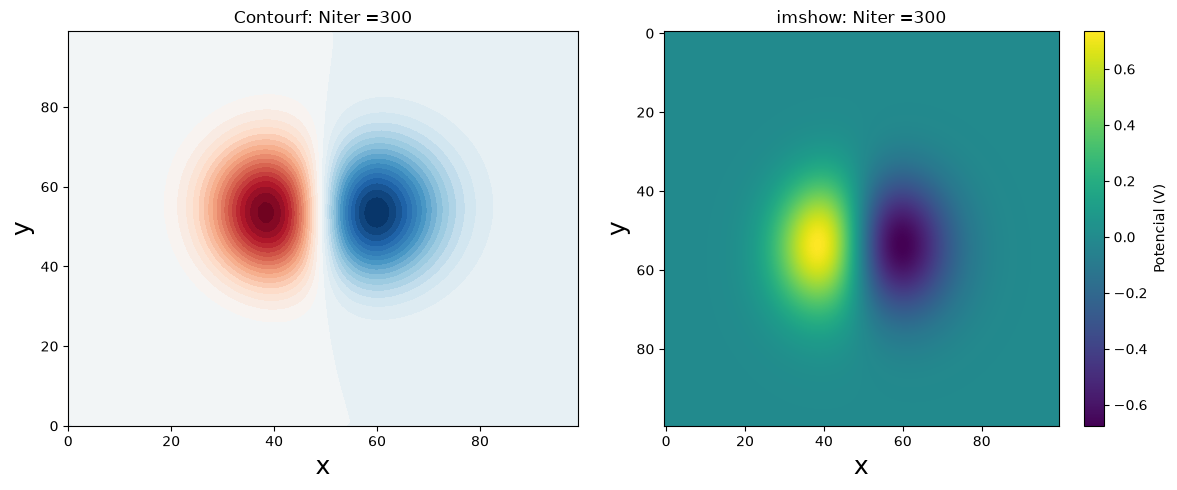

In [24]:
def capacitor(n_iter):
  V0, Nmax, L, d = 50, 100, 20, 10 # En orden: Voltaje inicial, N_iter_maximo, Longitud, Distancia placas 
  centro = int((d+Nmax)/2) # centro
  V_ini = np.zeros((Nmax, Nmax), float) # malla de ceros inicial

  # Actualización de malla con las dos placas, una con V0 y otra con -V0
  for k in range(0,L):
    V_ini[(centro-d) + k, centro - d] = V0
    V_ini[(centro-d) + k, centro] = -V0
    
    V_final = Laplace2D_FDM(V_ini, tol=10e-3, Nmax_iter=Niter)
  return V_final

V = capacitor(Niter)

plt.figure(figsize=(10,6))

# Crear figura
fig = plt.figure(figsize=(12,5))

# Superficie 3D
ax1 = fig.add_subplot(1,2,1)
ax1.contourf(V,levels = 40, cmap='RdBu_r')
ax1.set_title('Contourf: Niter =%.1d'%Niter)
ax1.set_xlabel("x",size=18)
ax1.set_ylabel("y",size=18)

# Campo eléctrico 2D
ax2 = fig.add_subplot(1,2,2)
im = ax2.imshow(V.copy(), interpolation="bilinear", ) # cmap="hot"

ax2.set_title('imshow: Niter =%.1d'%Niter)
ax2.set_xlabel("x",size=18)
ax2.set_ylabel("y",size=18)

# Barra de color (solo una, asociada al potencial)
fig.colorbar(im, ax=ax2, label='Potencial (V)')

plt.tight_layout()
plt.show()